Cuttable bond indices: [0, 1, 2, 4, 5, 9, 12, 13, 14, 15, 16]
Iter 0: sizes = [18]
Iter 1: sizes = [6, 12]
All fragments within size window; stopping.
SMILES: CCOC(=O)Nc1ccc(Cl)cc1C(C)CCO
Final fragment sizes (heavy atoms): [6, 12]
  Fragment 0: size=6, atoms=[0, 1, 2, 3, 4, 5], SMILES=CCOC(N)=O
  Fragment 1: size=12, atoms=[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], SMILES=CC(CCO)c1cccc(Cl)c1

Original molecule (with atom indices):


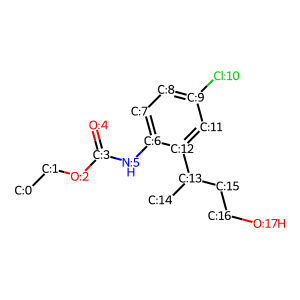

Fragments:


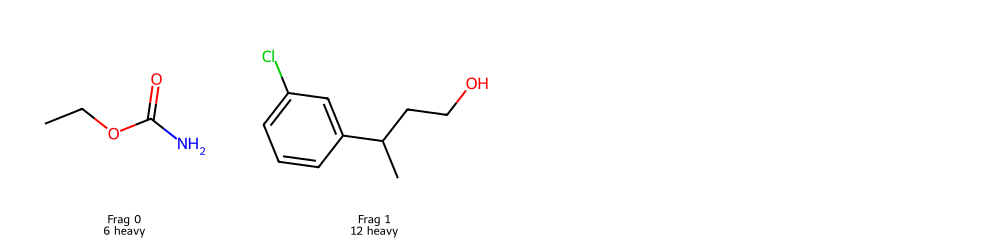

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

MIN_SIZE_DEFAULT = 6
MAX_SIZE_DEFAULT = 20

def find_cuttable_bonds(mol):
    """Single, non-ring bonds only."""
    cuttable = []
    for bond in mol.GetBonds():
        if bond.IsInRing():
            continue
        if bond.GetBondType() != Chem.BondType.SINGLE:
            continue
        cuttable.append(bond.GetIdx())
    return cuttable


def _build_fragment_adjacency(mol, fragments):
    atom_to_frag = {}
    for fi, atom_set in enumerate(fragments):
        for idx in atom_set:
            atom_to_frag[idx] = fi

    adj = {i: set() for i in range(len(fragments))}
    for bond in mol.GetBonds():
        a1 = bond.GetBeginAtomIdx()
        a2 = bond.GetEndAtomIdx()
        if a1 not in atom_to_frag or a2 not in atom_to_frag:
            continue
        f1 = atom_to_frag[a1]
        f2 = atom_to_frag[a2]
        if f1 != f2:
            adj[f1].add(f2)
            adj[f2].add(f1)
    return adj


def _components_after_cut(mol, atom_set, cut_bond_idx):
    bond = mol.GetBondWithIdx(cut_bond_idx)
    a_rm1 = bond.GetBeginAtomIdx()
    a_rm2 = bond.GetEndAtomIdx()

    local_adj = {a: set() for a in atom_set}
    for b in mol.GetBonds():
        a1 = b.GetBeginAtomIdx()
        a2 = b.GetEndAtomIdx()
        if a1 not in atom_set or a2 not in atom_set:
            continue
        if b.GetIdx() == cut_bond_idx:
            continue
        local_adj[a1].add(a2)
        local_adj[a2].add(a1)

    seen = set()
    comps = []
    for a in atom_set:
        if a in seen:
            continue
        stack = [a]
        comp = set()
        while stack:
            x = stack.pop()
            if x in seen:
                continue
            seen.add(x)
            comp.add(x)
            stack.extend(local_adj[x] - seen)
        comps.append(comp)

    return comps


def _try_merge_small_fragment(mol, fragments, min_size, max_size):
    sizes = [len(s) for s in fragments]
    adj = _build_fragment_adjacency(mol, fragments)

    small_idx = None
    for i, sz in enumerate(sizes):
        if sz < min_size:
            small_idx = i
            break
    if small_idx is None:
        return False, fragments

    neighbors = list(adj[small_idx])
    if not neighbors:
        return False, fragments  # isolated tiny bit

    target = 0.5 * (min_size + max_size)
    best_j = None
    best_score = 1e9

    for j in neighbors:
        merged_size = sizes[small_idx] + sizes[j]
        penalty = 0.0
        if merged_size < min_size:
            penalty += (min_size - merged_size) * 100.0
        if merged_size > max_size:
            penalty += (merged_size - max_size) * 10.0
        penalty += abs(merged_size - target)
        if penalty < best_score:
            best_score = penalty
            best_j = j

    if best_j is None:
        return False, fragments

    i, j = small_idx, best_j
    if j < i:
        i, j = j, i

    merged = fragments[i] | fragments[j]

    new_frags = []
    for k, fset in enumerate(fragments):
        if k == i:
            new_frags.append(merged)
        elif k == j:
            continue
        else:
            new_frags.append(fset)

    return True, new_frags


def _try_split_large_fragment(mol, fragments, cuttable_bonds, min_size, max_size):
    sizes = [len(s) for s in fragments]
    target = 0.5 * (min_size + max_size)

    large_idx = None
    for i, sz in enumerate(sizes):
        if sz > max_size:
            large_idx = i
            break
    if large_idx is None:
        return False, fragments

    atom_set = fragments[large_idx]
    candidates = []

    for bidx in cuttable_bonds:
        bond = mol.GetBondWithIdx(bidx)
        a1 = bond.GetBeginAtomIdx()
        a2 = bond.GetEndAtomIdx()
        if a1 not in atom_set or a2 not in atom_set:
            continue

        comps = _components_after_cut(mol, atom_set, bidx)
        if len(comps) != 2:
            continue

        s1 = len(comps[0])
        s2 = len(comps[1])

        penalty = 0.0
        for s in (s1, s2):
            if s < min_size:
                penalty += (min_size - s) * 100.0
            if s > max_size:
                penalty += (s - max_size) * 10.0
            penalty += abs(s - target)

        candidates.append((penalty, comps))

    if not candidates:
        return False, fragments

    candidates.sort(key=lambda x: x[0])
    comp1, comp2 = candidates[0][1]

    new_frags = []
    for i, fset in enumerate(fragments):
        if i == large_idx:
            new_frags.append(comp1)
            new_frags.append(comp2)
        else:
            new_frags.append(fset)

    return True, new_frags


def _submol_from_atom_set(mol, atom_set):
    amap = {}
    emol = Chem.RWMol()
    for old_idx in sorted(atom_set):
        atom = mol.GetAtomWithIdx(old_idx)
        new_atom = Chem.Atom(atom.GetAtomicNum())
        new_idx = emol.AddAtom(new_atom)
        amap[old_idx] = new_idx

    for bond in mol.GetBonds():
        a1 = bond.GetBeginAtomIdx()
        a2 = bond.GetEndAtomIdx()
        if a1 in atom_set and a2 in atom_set:
            emol.AddBond(amap[a1], amap[a2], bond.GetBondType())

    frag = emol.GetMol()
    Chem.SanitizeMol(frag)
    return frag


def partition_molecule_size_constrained(
    mol,
    min_size=MIN_SIZE_DEFAULT,
    max_size=MAX_SIZE_DEFAULT,
    max_iter=200,
    verbose=False,
):
    heavy_atoms = [
        i for i, a in enumerate(mol.GetAtoms())
        if a.GetAtomicNum() > 1
    ]
    if len(heavy_atoms) <= min_size:
        if verbose:
            print("Molecule has <= min_size heavy atoms; single fragment.")
        return [set(heavy_atoms)], [_submol_from_atom_set(mol, set(heavy_atoms))]

    fragments = [set(heavy_atoms)]
    cuttable_bonds = find_cuttable_bonds(mol)
    if verbose:
        print("Cuttable bond indices:", cuttable_bonds)

    for it in range(max_iter):
        sizes = [len(s) for s in fragments]
        if verbose:
            print(f"Iter {it}: sizes = {sizes}")

        if all(min_size <= s <= max_size for s in sizes):
            if verbose:
                print("All fragments within size window; stopping.")
            break

        changed = False

        if any(s > max_size for s in sizes):
            changed, fragments = _try_split_large_fragment(
                mol, fragments, cuttable_bonds, min_size, max_size
            )
            if changed:
                continue

        if any(s < min_size for s in sizes):
            changed, fragments = _try_merge_small_fragment(
                mol, fragments, min_size, max_size
            )
            if changed:
                continue

        if verbose:
            print("No further merges/splits possible; stopping.")
        break

    frag_mols = [_submol_from_atom_set(mol, s) for s in fragments]
    final_sizes = [len(s) for s in fragments]

    if verbose and not all(min_size <= s <= max_size for s in final_sizes):
        print(
            f"Warning: some fragments still outside {min_size}-{max_size}: "
            f"{final_sizes}"
        )

    return fragments, frag_mols


def visualize_size_constrained_fragments(
    smiles,
    min_size=MIN_SIZE_DEFAULT,
    max_size=MAX_SIZE_DEFAULT,
    verbose=True,
):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Could not parse SMILES: {smiles}")

    frag_sets, frag_mols = partition_molecule_size_constrained(
        mol, min_size=min_size, max_size=max_size, verbose=verbose
    )

    print(f"SMILES: {smiles}")
    print(f"Final fragment sizes (heavy atoms): {[len(s) for s in frag_sets]}")
    for i, (s, m) in enumerate(zip(frag_sets, frag_mols)):
        print(
            f"  Fragment {i}: size={len(s)}, atoms={sorted(s)}, "
            f"SMILES={Chem.MolToSmiles(m)}"
        )

    mol_idx = Chem.Mol(mol)
    for a in mol_idx.GetAtoms():
        a.SetProp("molAtomMapNumber", str(a.GetIdx()))
    print("\nOriginal molecule (with atom indices):")
    display(Draw.MolToImage(mol_idx, size=(300, 300)))

    legends = [f"Frag {i}\n{len(s)} heavy" for i, s in enumerate(frag_sets)]
    print("Fragments:")
    img = Draw.MolsToGridImage(
        frag_mols,
        molsPerRow=4,
        subImgSize=(250, 250),
        legends=legends,
    )
    display(img)


# Example
example_smiles = "CCOC(=O)Nc1ccc(Cl)cc1C(C)CCO"
visualize_size_constrained_fragments(
    example_smiles,
    min_size=6,
    max_size=15,
    verbose=True,
)
